# New Song Prediction and Music Recommendations

## What this notebook does

We have 12 songs in recommend.csv that represent what a hypothetical
user has been listening to. Our job is to:

1. Load and preprocess these 12 songs the exact same way we processed
   the 28,362 training songs
2. Use our trained KMeans model to predict which cluster each song
   belongs to
3. Find songs from the training set in the same cluster
4. Recommend those songs to the user

## Why this works as a recommendation system

If Song A and Song B are in the same cluster they share similar lyrical
DNA — similar scores across all 17 lyric theme features.

If we know a user enjoys Song A then they are likely to enjoy other
songs that share the same lyrical character as Song A. We find those
songs by looking inside the same cluster.

This is called content-based filtering — we are matching songs on
their own characteristics rather than on what other users listened to.

## The most important rule in this notebook

Every preprocessing step must be identical to what we did in Notebook 2.
Same columns dropped. Same scaler. Same order of columns.

If we deviate even slightly — for example by scaling the test data
with a new scaler — the test songs end up on a completely different
numerical scale than the training songs and the model predictions
will be wrong.

In [23]:
#importing the neccesssary libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


In [24]:
# Loading the 12 test songs
df_test = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/recommend - recommend.csv')
df_test = df_test.rename(columns={'Unnamed: 0': 'song_id'})
df_test = df_test.set_index('song_id')

# Loading the trained KMeans model saved in our modeling section
model = joblib.load('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/kmeans_model.pkl')

# Loading the StandardScaler saved in our transform section
# We MUST use this exact scaler so the test songs are on the same scale
# as the training songs the model learned from
scaler = joblib.load('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/scaler.pkl')

# Loading the training songs with cluster labels  saved in our modeling section
# We use this to find songs from the same cluster to recommend
df_train_labeled = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_with_clusters.csv', index_col=0)

# Loading the cleaned training features so we know which columns to keep
df_train_features = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_cleaned_unscaled.csv', index_col=0)

print(f"Test songs loaded:          {df_test.shape[0]} songs")
print(f"Training songs with labels: {df_train_labeled.shape[0]} songs")
print()
print("Test songs in this dataset:")
print(df_test[['artist_name', 'track_name', 'genre']].to_string())

Test songs loaded:          10 songs
Training songs with labels: 28362 songs

Test songs in this dataset:
                      artist_name            track_name    genre
song_id                                                         
76885                    godsmack                immune     rock
65394                dennis brown         second chance   reggae
10980            the black crowes           sister luck      pop
842               jerry lee lewis   your cheating heart      pop
2764                    paul anka              eso beso      pop
54425                noro morales              silencio     jazz
77225    rage against the machine      pistol grip pump     rock
42962                       taste       railway and gun    blues
28825                randy travis  messin' with my mind  country
16881                    paramore           playing god      pop


## Let us inspect the Test Data

Before preprocessing we look at the test data carefully.
We need to know:
- What columns it has
- Whether it has any extra columns that the training data does not have
- Whether it has any null values

The recommend.csv file has one extra column called like/girls that
does not exist in the training data. We must drop it.

If we leave it in then our feature matrix will have 18 columns
but the scaler was fitted on 17 columns — it will throw an error.

In [25]:
print("Test data columns:")
print(df_test.columns.tolist())
print()
print("Training feature columns (what the model expects):")
print(df_train_features.columns.tolist())
print()

# Find columns in test that are NOT in training features
extra_cols = [c for c in df_test.columns if c not in df_train_features.columns]
print(f"Extra columns in test data that need to be dropped: {extra_cols}")
print()

# Check for null values
print(f"Null values in test data: {df_test.isnull().sum().sum()}")

Test data columns:
['artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'like/girls', 'sadness', 'feelings', 'topic', 'age']

Training feature columns (what the model expects):
['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']

Extra columns in test data that need to be dropped: ['artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'like/girls', 'topic']

Null values in test data: 0


## Preprocessing  the Test Data

We apply the exact same transformations as Notebook 2:

1. Drop all non-numeric columns
2. Drop the extra like/girls column that only exists in the test file
3. Keep only the columns the model was trained on in the same order
4. Handle any null values
5. Scale using the saved scaler with transform() not fit_transform()

The difference between transform() and fit_transform() is critical:
- fit_transform() learns new mean/std from the data then applies scaling
- transform() uses the already-learned mean/std from training data

We must use transform() on test data because the scaler already has
the correct mean and std values from 28,362 training songs.
Using fit_transform() on 12 songs would learn completely wrong
parameters and produce garbage predictions.

In [26]:
# Drop all non-numeric / non-feature columns
cols_to_drop = [
    'artist_name',
    'track_name',
    'release_date',
    'genre',
    'topic',
    'lyrics',
    'like/girls'   # extra column that only exists in the test file
]

df_test_features = df_test.drop(
    columns=[c for c in cols_to_drop if c in df_test.columns]
)

print(f"Shape after dropping non-feature columns: {df_test_features.shape}")
print()

# Keep only the columns our model was trained on and in the same order
training_cols = df_train_features.columns.tolist()
df_test_features = df_test_features[training_cols]

print(f"Shape after aligning columns to training data: {df_test_features.shape}")
print()
print(f"Columns match training data: {df_test_features.columns.tolist() == training_cols}")

Shape after dropping non-feature columns: (10, 17)

Shape after aligning columns to training data: (10, 17)

Columns match training data: True


In [27]:
# Drop all non-numeric / non-feature columns
cols_to_drop = [
    'artist_name',
    'track_name',
    'release_date',
    'genre',
    'topic',
    'lyrics',
    'like/girls'
]

df_test_features = df_test.drop(
    columns=[c for c in cols_to_drop if c in df_test.columns]
)

print(f"Shape after dropping non-feature columns: {df_test_features.shape}")
print()

# Check what columns the scaler expects
print("Columns the scaler was fitted on:")
print(scaler.feature_names_in_.tolist())
print()
print("Columns we currently have:")
print(df_test_features.columns.tolist())

Shape after dropping non-feature columns: (10, 17)

Columns the scaler was fitted on:
['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']

Columns we currently have:
['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']


In [28]:
# Handle any null values by filling with the median of each column
# (even if there are none this is good defensive practice)
null_count = df_test_features.isnull().sum().sum()
print(f"Null values before fill: {null_count}")

df_test_features = df_test_features.fillna(df_test_features.median())
print(f"Null values after fill:  {df_test_features.isnull().sum().sum()}")
print()

# Force all columns to numeric type just in case
df_test_features = df_test_features.apply(pd.to_numeric, errors='coerce')
df_test_features = df_test_features.fillna(df_test_features.median())

# Scale using the SAME scaler fitted on training data
# transform() only — never fit_transform() on test data
X_test_scaled = scaler.transform(df_test_features)

print(f"Scaled test matrix shape: {X_test_scaled.shape}")
print()
print("Test data is preprocessed and ready for prediction.")

Null values before fill: 0
Null values after fill:  0

Scaled test matrix shape: (10, 17)

Test data is preprocessed and ready for prediction.


## Predict Cluster for Each Test Song

We pass the scaled test data through our trained KMeans model.

The model measures how close each test song is to each of the
cluster centroids it learned during training and assigns the song
to the nearest centroid.

This is the moment where our recommendation system comes to life —
each test song gets placed into one of the k clusters we discovered
in the training data.

In [29]:
# Predict which cluster each test song belongs to
test_cluster_labels = model.predict(X_test_scaled)

# Add cluster labels to the test DataFrame
df_test_result = df_test.copy()
df_test_result['cluster'] = test_cluster_labels

print("Cluster assignments for each test song:")
print()
print(f"{'Artist':<30} {'Track':<35} {'Genre':<12} {'Cluster'}")
print("-" * 85)
for _, row in df_test_result.iterrows():
    print(f"{str(row['artist_name']):<30} "
          f"{str(row['track_name']):<35} "
          f"{str(row['genre']):<12} "
          f"Cluster {row['cluster']}")

Cluster assignments for each test song:

Artist                         Track                               Genre        Cluster
-------------------------------------------------------------------------------------
godsmack                       immune                              rock         Cluster 1
dennis brown                   second chance                       reggae       Cluster 0
the black crowes               sister luck                         pop          Cluster 2
jerry lee lewis                your cheating heart                 pop          Cluster 4
paul anka                      eso beso                            pop          Cluster 5
noro morales                   silencio                            jazz         Cluster 2
rage against the machine       pistol grip pump                    rock         Cluster 6
taste                          railway and gun                     blues        Cluster 4
randy travis                   messin' with my mind              

## Understanding What Each Cluster Means

Before generating recommendations we remind ourselves what each
cluster represents by recreating the cluster profiles from the
labeled training data.

The cluster profile shows the average lyric theme score for every
cluster. This tells us the lyrical personality of each cluster
in plain terms — for example high gospel and low violence means
that cluster contains spiritual and faith-oriented songs.

We use this to explain to the user not just WHAT we are recommending
but WHY — what lyrical characteristics connect the songs they
already listen to with the songs we are suggesting.

In [30]:
# Define the lyric theme columns
theme_cols = [
    'dating', 'violence', 'world/life', 'night/time',
    'shake the audience', 'family/gospel', 'romantic',
    'communication', 'obscene', 'music', 'movement/places',
    'light/visual perceptions', 'family/spiritual', 'sadness'
]

# Recreate cluster profiles from the labeled training data
# We check which theme columns are available in the labeled data
available_theme_cols = [c for c in theme_cols if c in df_train_labeled.columns]
cluster_profiles = df_train_labeled.groupby('cluster')[available_theme_cols].mean()

print("Cluster profiles — average theme scores:")
print()
print(cluster_profiles.round(3).to_string())
print()

# Show which clusters the test songs landed in
test_clusters_used = sorted(df_test_result['cluster'].unique())
print("Clusters assigned to your test songs:")
print()
for c in test_clusters_used:
    top3 = cluster_profiles.loc[c].nlargest(3).index.tolist()
    songs_here = (df_test_result['cluster'] == c).sum()
    print(f"  Cluster {c}: top themes = {', '.join(top3)}")
    print(f"             {songs_here} of your 12 test songs landed here")
    print()

Cluster profiles — average theme scores:

         dating  violence  world/life  night/time  shake the audience  family/gospel  romantic  communication  obscene  music  movement/places  light/visual perceptions  family/spiritual  sadness
cluster                                                                                                                                                                                            
0         0.033     0.040       0.049       0.398               0.019          0.018     0.030          0.076    0.031  0.030            0.045                     0.042             0.016    0.057
1         0.017     0.042       0.429       0.031               0.015          0.016     0.029          0.079    0.022  0.028            0.043                     0.054             0.030    0.062
2         0.013     0.433       0.054       0.031               0.016          0.016     0.021          0.073    0.026  0.023            0.052                     0.058      

## Now lets Generate our Music Recommendations

For each of the 12 test songs we:
1. Identify which cluster it was assigned to
2. Find all training songs in that same cluster
3. Sample 5 of them as recommendations
4. Print them with the lyrical themes that connect them

The logic is transparent and interpretable:
Songs in the same cluster share similar lyrical DNA. If the user
enjoys a song with certain lyrical characteristics they are likely
to enjoy other songs that score similarly across those same features.

The cluster acts as a lyrical fingerprint — matching new songs
to what the user already loves based on content rather than
on genre labels or listening history from other users.

In [31]:
all_recommendations = []

print("=" * 70)
print("PERSONALIZED MUSIC RECOMMENDATIONS")
print("=" * 70)

for _, test_row in df_test_result.iterrows():
    cluster_id = int(test_row['cluster'])

    # Get top 3 themes for this cluster
    top_themes = cluster_profiles.loc[cluster_id].nlargest(3).index.tolist()

    # Find all training songs in the same cluster
    same_cluster = df_train_labeled[df_train_labeled['cluster'] == cluster_id]

    # Sample 5 recommendations from that cluster
    n_recs = min(5, len(same_cluster))
    recommended = same_cluster[['artist_name', 'track_name', 'genre']].sample(
        n_recs, random_state=42
    )

    print()
    print(f"  Because you listened to:")
    print(f"  {test_row['artist_name']} — {test_row['track_name']} ({test_row['genre']})")
    print(f"  Cluster {cluster_id} | Top themes: {', '.join(top_themes)}")
    print()
    print(f"  We recommend:")
    for _, rec in recommended.iterrows():
        print(f"    → {str(rec['artist_name']):<28} "
              f"— {str(rec['track_name']):<30} "
              f"({rec['genre']})")

        all_recommendations.append({
            'listened_to_artist':  test_row['artist_name'],
            'listened_to_song':    test_row['track_name'],
            'listened_to_genre':   test_row['genre'],
            'cluster':             cluster_id,
            'cluster_themes':      ', '.join(top_themes),
            'recommended_artist':  rec['artist_name'],
            'recommended_song':    rec['track_name'],
            'recommended_genre':   rec['genre']
        })

    print()
    print("  " + "-" * 66)

print()
print("=" * 70)
print(f"Total recommendations generated: {len(all_recommendations)}")
print("=" * 70)

PERSONALIZED MUSIC RECOMMENDATIONS

  Because you listened to:
  godsmack — immune (rock)
  Cluster 1 | Top themes: world/life, communication, sadness

  We recommend:
    → dolly parton                 — wildflowers                    (country)
    → the cranberries              — dreaming my dreams             (pop)
    → rebelution                   — take on anything               (reggae)
    → chicago                      — will you still love me?        (rock)
    → willie nelson                — wonderful future               (country)

  ------------------------------------------------------------------

  Because you listened to:
  dennis brown — second chance (reggae)
  Cluster 0 | Top themes: night/time, communication, sadness

  We recommend:
    → herbs                        — home grown                     (reggae)
    → lightnin' hopkins            — so long baby                   (country)
    → pet shop boys                — always on my mind              (pop)
    →

## Visualize Which Clusters the Test Songs Landed In

A bar chart showing how many of the 12 test songs landed in each
cluster gives us a quick visual summary of the user's listening profile.

If most test songs land in 2 or 3 clusters it tells us the user
has a fairly focused taste in lyrical content.
If they spread across many clusters it tells us the user has
diverse and wide-ranging musical tastes.

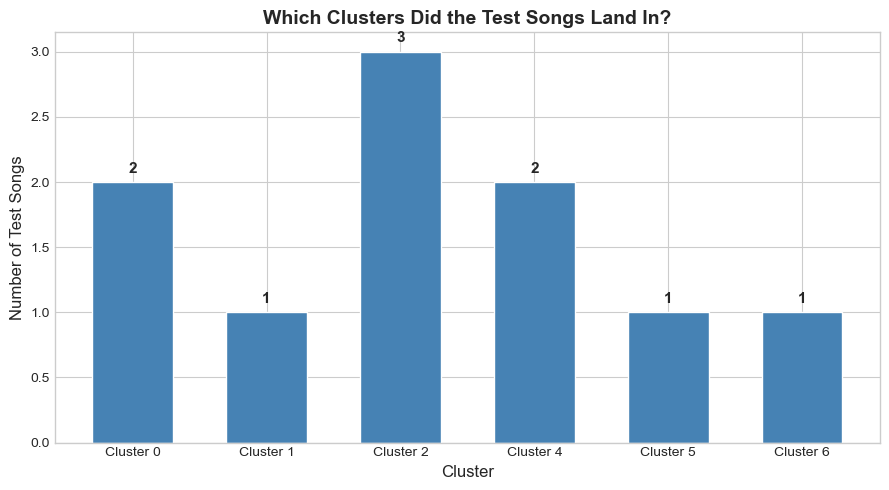

User listening profile:
  Cluster 0 (2 songs): night/time, communication, sadness
  Cluster 1 (1 songs): world/life, communication, sadness
  Cluster 2 (3 songs): violence, communication, light/visual perceptions
  Cluster 4 (2 songs): sadness, communication, world/life
  Cluster 5 (1 songs): romantic, communication, sadness
  Cluster 6 (1 songs): obscene, movement/places, communication


In [33]:
# Count how many test songs landed in each cluster
cluster_counts = df_test_result['cluster'].value_counts().sort_index()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    [f'Cluster {c}' for c in cluster_counts.index],
    cluster_counts.values,
    color='steelblue',
    edgecolor='white',
    width=0.6
)

# Add count labels on top of each bar
for bar, count in zip(bars, cluster_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(count),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Test Songs', fontsize=12)
plt.title('Which Clusters Did the Test Songs Land In?',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

print("User listening profile:")
for cluster_id, count in cluster_counts.items():
    top3 = cluster_profiles.loc[cluster_id].nlargest(3).index.tolist()
    print(f"  Cluster {cluster_id} ({count} songs): {', '.join(top3)}")

In [34]:
# Save the test songs with their cluster assignments
df_test_result.to_csv(
    '/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/test_songs_with_clusters.csv',
    index=True
)
print("Saved: test_songs_with_clusters.csv")

# Save the full recommendations table
df_recommendations = pd.DataFrame(all_recommendations)
df_recommendations.to_csv(
    '/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/recommendations.csv',
    index=False
)
print("Saved: recommendations.csv")

print()
print("Full recommendations table:")
print()
print(df_recommendations[[
    'listened_to_artist',
    'listened_to_song',
    'cluster',
    'recommended_artist',
    'recommended_song',
    'recommended_genre'
]].to_string(index=False))

Saved: test_songs_with_clusters.csv
Saved: recommendations.csv

Full recommendations table:

      listened_to_artist     listened_to_song  cluster      recommended_artist                        recommended_song recommended_genre
                godsmack               immune        1            dolly parton                             wildflowers           country
                godsmack               immune        1         the cranberries                      dreaming my dreams               pop
                godsmack               immune        1              rebelution                        take on anything            reggae
                godsmack               immune        1                 chicago                 will you still love me?              rock
                godsmack               immune        1           willie nelson                        wonderful future           country
            dennis brown        second chance        0                   herbs       